# TP3 – Prétraitement de Données | Machine Learning 2025/2026
**Dataset :** Used Cars Price Prediction — cars.com  
**Professeur :** Ayoub Esswidi  
**Objectif :** Analyser, pré-traiter et modéliser les données pour prédire le prix des voitures d'occasion.

 **PRENOM & NOM :** ILYAS MACHHOUL 

---

### 1. Import des bibliothèques essentielles

In [7]:
%pip install category_encoders xgboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import category_encoders as ce
from xgboost import XGBRegressor



Note: you may need to restart the kernel to use updated packages.


### 2. Chargement & Inspection initiale

In [8]:
df = pd.read_csv("used_cars.csv")
print("── 5 premières lignes ──")
df.head()

── 5 premières lignes ──


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [9]:
print("── 5 dernières lignes ──")
df.tail()

── 5 dernières lignes ──


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"
4008,BMW,X3 xDrive30i,2020,"43,000 mi.",Gasoline,248.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Brown,At least 1 accident or damage reported,Yes,"$40,000"


In [10]:
print("── Échantillon aléatoire de 7 observations ──")
df.sample(7, random_state=42)

── Échantillon aléatoire de 7 observations ──


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
2580,Lexus,IS 300 Base,2018,"50,992 mi.",Gasoline,260.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,White,Gray,At least 1 accident or damage reported,Yes,"$28,000"
3660,Chevrolet,Impala Base,2004,"64,500 mi.",Gasoline,180.0HP 3.4L V6 Cylinder Engine Gasoline Fuel,A/T,Beige,Beige,None reported,Yes,"$5,900"
897,RAM,2500 SLT,2017,"86,000 mi.",Diesel,350.0HP 6.7L Straight 6 Cylinder Engine Diesel...,6-Speed A/T,Gray,Gray,At least 1 accident or damage reported,Yes,"$41,000"
2091,Mercedes-Benz,SL-Class SL 550,2013,"24,933 mi.",Gasoline,429.0HP 4.6L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Silver,Red,At least 1 accident or damage reported,Yes,"$40,250"
1044,Ford,Shelby GT350R Base,2018,"18,500 mi.",Gasoline,526.0HP 5.2L 8 Cylinder Engine Gasoline Fuel,M/T,Blue,Black,At least 1 accident or damage reported,Yes,"$77,999"
2320,GMC,Yukon SLT,2018,"85,500 mi.",Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,A/T,Black,Black,At least 1 accident or damage reported,Yes,"$35,899"
465,Volvo,V60 Cross Country T5,2020,"10,500 mi.",Gasoline,250.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,8-Speed A/T,White,Black,None reported,Yes,"$36,000"


### 3. Résumé de la structure du DataFrame

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


### 4. Forme du DataFrame

In [12]:
print(f"Nombre de lignes   : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de lignes   : 4009
Nombre de colonnes : 12


### 5. Description statistique

In [13]:
df.describe(include='all')# Affiche les statistiques descriptives pour toutes les colonnes, y compris les variables catégorielles.

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009.000000,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,NaN,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,NaN,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,NaN,16,3309,52,1037,905,2025,2910,3413,39
mean,NaN,NaN,2015.515590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,6.104816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1974.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 6. Lignes dupliquées & Valeurs manquantes

In [14]:
print(f"Lignes dupliquées : {df.duplicated().sum()}")
print("Valeurs manquantes par colonne :")
missing = df.isnull().sum()
display(missing[missing > 0].rename("Manquantes").to_frame())

Lignes dupliquées : 0
Valeurs manquantes par colonne :


,Manquantes
fuel_type,170
accident,113
clean_title,596


### 1. Traitement des valeurs manquantes (1ʳᵉ passe)

In [15]:
# fuel_type  → mode (valeur la plus fréquente)
# accident   → 'None reported' (inconnu ≠ accident confirmé)
# clean_title→ 'No'  (inconnu ≠ titre propre confirmé)
df["fuel_type"]   = df["fuel_type"].fillna(df["fuel_type"].mode()[0])
df["accident"]    = df["accident"].fillna("None reported")
df["clean_title"] = df["clean_title"].fillna("No")

print("Valeurs manquantes restantes :", df.isnull().sum().sum())

Valeurs manquantes restantes : 0


### 2. Conversion en types numériques (milage, price)

In [16]:
# milage : supprime les virgules et " mi." → int
df["milage"] = (
    df["milage"]
    .str.replace(",", "", regex=False)
    .str.replace(" mi.", "", regex=False)
    .astype(int)
)

# price : supprime "$" et virgules → int
df["price"] = (
    df["price"]
    .str.replace(r"[$,]", "", regex=True)
    .astype(int)
)

print("Types après conversion :")
print(df[["milage", "price"]].dtypes)

Types après conversion :
milage    int64
price     int64
dtype: object


### 3. Calcul de l'âge du véhicule (remplace model_year)

In [17]:
CURRENT_YEAR = 2026

def compute_age(year: int) -> int:
    """Retourne l'âge d'un véhicule en années à partir de son année de fabrication."""
    return CURRENT_YEAR - year

df["Age"] = df["model_year"].apply(compute_age)# applique cette fct sur  tous les colonne 
df.drop(columns=["model_year"], inplace=True)


df[["Age"]].head()

,Age
0,13
1,5
2,4
3,11
4,5


### 4. Nettoyage de la colonne `transmission` → 3 catégories

In [18]:
def categorize_transmission(val: str) -> str:
    v = str(val).lower()# convertit en minuscules pour faciliter la recherche de mots-clés
    if "manual" in v or "m/t" in v:
        return "Manual"
    if "automatic" in v or "a/t" in v or "cvt" in v:
        return "Automatic"
    return "Other"

df["transmission"] = df["transmission"].apply(categorize_transmission)
print("Distribution des catégories de transmission :")
df["transmission"].value_counts()

Distribution des catégories de transmission :


transmission
Automatic    3209
Other         426
Manual        374
Name: count, dtype: int64

### 5. One-Hot Encoding de la transmission

In [19]:
ohe_trans = pd.get_dummies(df["transmission"], prefix="", prefix_sep="")#cree des colonne de la colonne categorile principalle(true/false)
ohe_trans.columns = [c.lower() for c in ohe_trans.columns]   # automatic / manual / other
ohe_trans = ohe_trans.astype(int)


df = pd.concat([df.drop(columns=["transmission"]),
                ohe_trans[["automatic", "manual", "other"]]], axis=1)

print("Extrait après OHE :")
df[["automatic", "manual", "other"]].head()

Extrait après OHE :


,automatic,manual,other
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


### 6. Extraction de `Horsepower` & `Engine_Cylinder` depuis `engine`

In [20]:
def extract_horsepower(engine: str) -> float:
    m = re.search(r"([\d.]+)\s*HP", str(engine), re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

df["Horsepower"] = df["engine"].apply(extract_horsepower)

def extract_cylinders(engine: str) -> float:
    m = re.search(r"(\d+)\s*Cylinder", str(engine), re.IGNORECASE)
    if m:
        return float(m.group(1))
    m2 = re.search(r"[VIL](\d+)", str(engine))
    return float(m2.group(1)) if m2 else np.nan

df["Cylinder"] = df["engine"].apply(extract_cylinders)

def extract_liters(engine: str) -> float:
    m = re.search(r"([\d.]+)\s*L\b", str(engine), re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

df["Liters"] = df["engine"].apply(extract_liters)

print(f"Horsepower      — NaN : {df['Horsepower'].isna().sum()}")
print(f"Cylinder — NaN : {df['Cylinder'].isna().sum()}")
print(f"Liters   — NaN : {df['Liters'].isna().sum()}")
df[["Horsepower", "Cylinder", "Liters"]].head()

Horsepower      — NaN : 808
Cylinder — NaN : 440
Liters   — NaN : 375


,Horsepower,Cylinder,Liters
0,300.0,6.0,3.7
1,NaN,6.0,3.8
2,NaN,NaN,NaN
3,354.0,6.0,3.5
4,NaN,4.0,2.0


### 7. Traitement des valeurs manquantes (2ᵉ passe — après extraction)

In [21]:
df["Horsepower"]      = df["Horsepower"].fillna(df["Horsepower"].median()) #-fillna rempalce les val monquent par qelque chose (ici la mediane)
df["Cylinder"] = df["Cylinder"].fillna(df["Cylinder"].median())
df["Liters"]         = df["Liters"].fillna(df["Liters"].median())

print("Valeurs manquantes restantes :", df.isnull().sum())

Valeurs manquantes restantes : brand          0
model          0
milage         0
fuel_type      0
engine         0
ext_col        0
int_col        0
accident       0
clean_title    0
price          0
Age            0
automatic      0
manual         0
other          0
Horsepower     0
Cylinder       0
Liters         0
dtype: int64


### 8. Traitements complémentaires

In [22]:
# Encodage binaire : accident et clean_title
df["accident"]    = df["accident"].apply(lambda x: 1 if "accident" in str(x).lower() else 0)
df["clean_title"] = df["clean_title"].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0)

# Suppression des colonnes non utiles pour la modélisation
df.drop(columns=["model", "engine"], inplace=True)

# Suppression des outliers de prix (> 99e percentile)
price_cap = df["price"].quantile(0.99)
print(f"Seuil prix (99e pct) : {price_cap:,.0f} $  — {(df['price'] > price_cap).sum()} lignes supprimées")
df = df[df["price"] <= price_cap].reset_index(drop=True)

print(f"\nDataFrame final : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.info()

Seuil prix (99e pct) : 272,713 $  — 41 lignes supprimées

DataFrame final : 3968 lignes × 15 colonnes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3968 entries, 0 to 3967
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   brand        3968 non-null   object 
 1   milage       3968 non-null   int64  
 2   fuel_type    3968 non-null   object 
 3   ext_col      3968 non-null   object 
 4   int_col      3968 non-null   object 
 5   accident     3968 non-null   int64  
 6   clean_title  3968 non-null   int64  
 7   price        3968 non-null   int64  
 8   Age          3968 non-null   int64  
 9   automatic    3968 non-null   int64  
 10  manual       3968 non-null   int64  
 11  other        3968 non-null   int64  
 12  Horsepower   3968 non-null   float64
 13  Cylinder     3968 non-null   float64
 14  Liters       3968 non-null   float64
dtypes: float64(3), int64(8), object(4)
memory usage: 465.1+ KB


In [23]:
df.head()

,brand,milage,fuel_type,ext_col,int_col,accident,clean_title,price,Age,automatic,manual,other,Horsepower,Cylinder,Liters
0,Ford,51000,E85 Flex Fuel,Black,Black,1,1,10300,13,1,0,0,300.0,6.0,3.7
1,Hyundai,34742,Gasoline,Moonlight Cloud,Gray,1,1,38005,5,1,0,0,310.0,6.0,3.8
2,Lexus,22372,Gasoline,Blue,Black,0,0,54598,4,1,0,0,310.0,6.0,3.5
3,INFINITI,88900,Hybrid,Black,Black,0,1,15500,11,1,0,0,354.0,6.0,3.5
4,Audi,9835,Gasoline,Glacier White Metallic,Black,0,0,34999,5,1,0,0,310.0,4.0,2.0


---
## 🅒 Exploratory Data Analysis (EDA)

### 1. Distribution des marques (BarPlot)

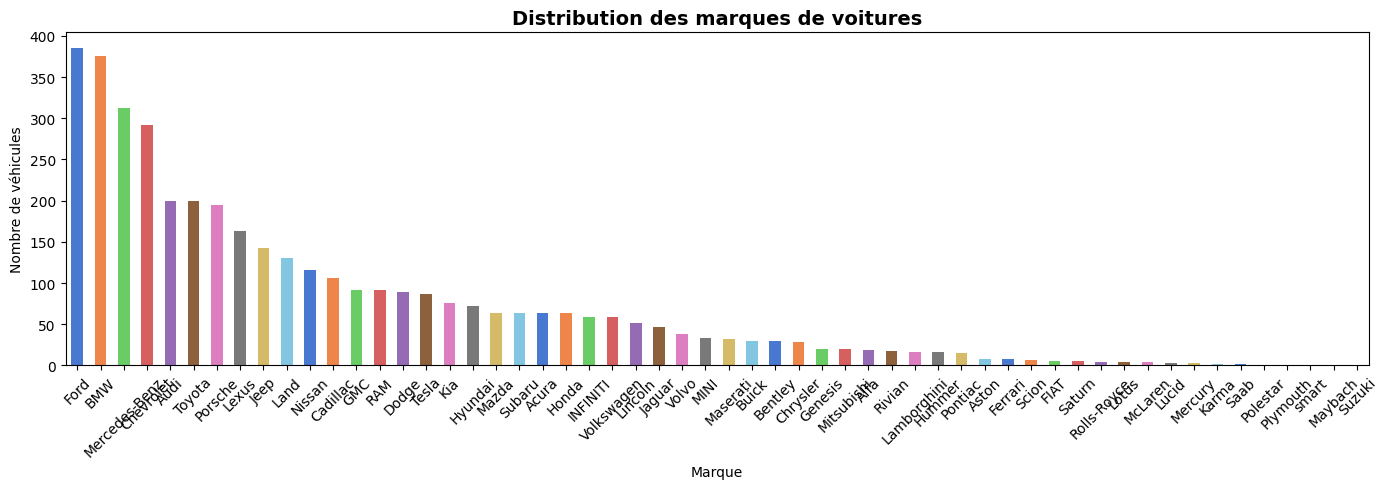

In [24]:
fig, ax = plt.subplots(figsize=(14, 5))
brand_counts = df["brand"].value_counts()
brand_counts.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(brand_counts)))
ax.set_title("Distribution des marques de voitures", fontsize=14, fontweight="bold")
ax.set_xlabel("Marque")
ax.set_ylabel("Nombre de véhicules")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 2. Variable cible (`price`) en fonction de différentes variables

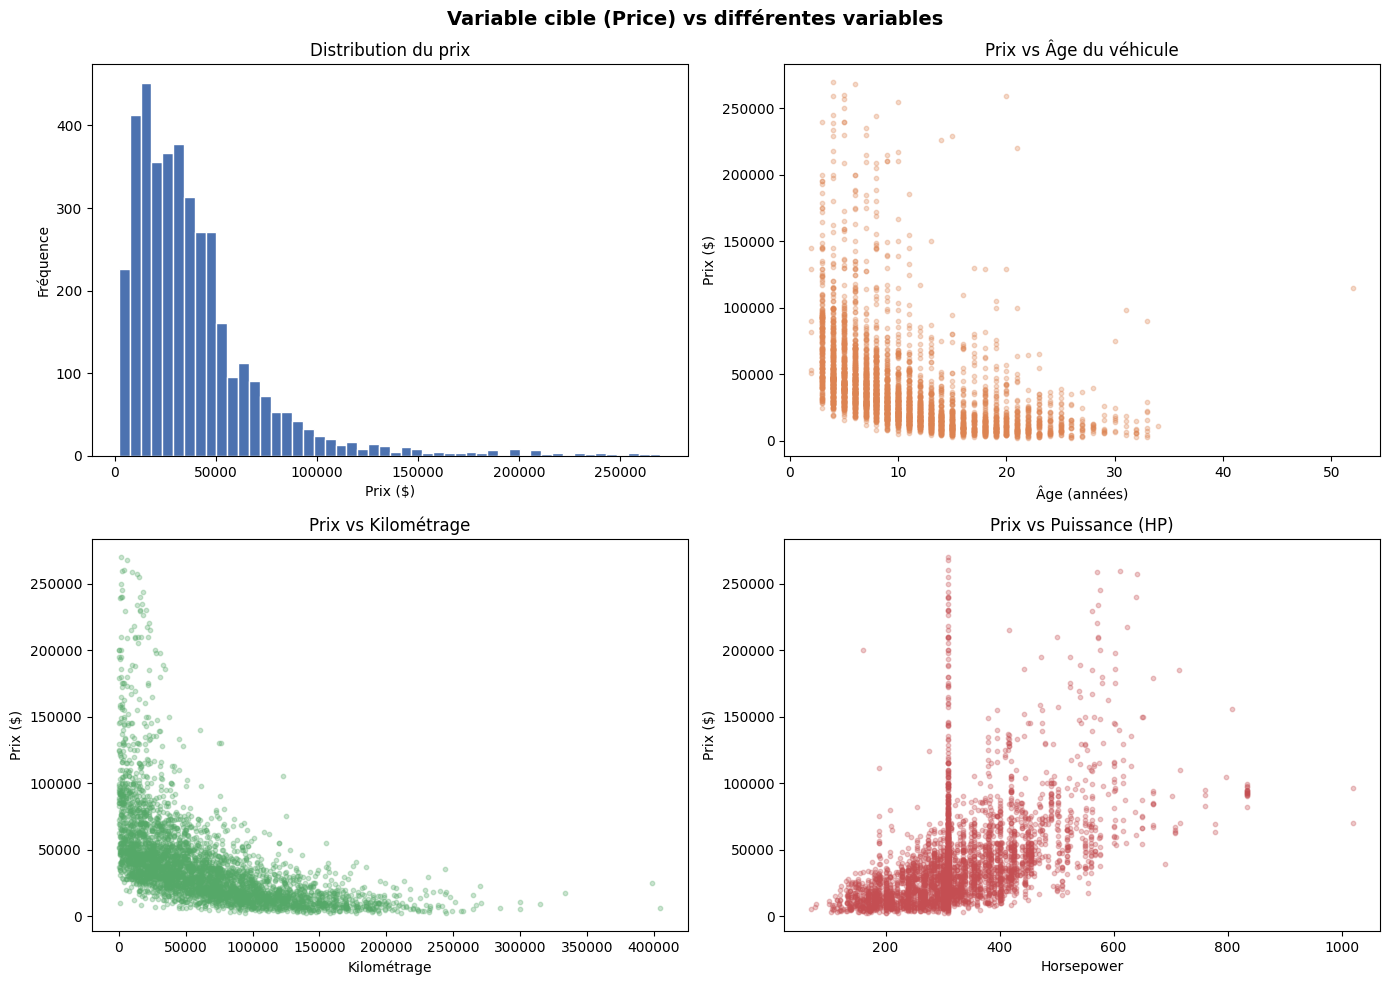

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution du prix
axes[0, 0].hist(df["price"], bins=50, color="#4C72B0", edgecolor="white")
axes[0, 0].set_title("Distribution du prix")
axes[0, 0].set_xlabel("Prix ($)")
axes[0, 0].set_ylabel("Fréquence")

# Prix vs Âge
axes[0, 1].scatter(df["Age"], df["price"], alpha=0.3, s=10, color="#DD8452")
axes[0, 1].set_title("Prix vs Âge du véhicule")
axes[0, 1].set_xlabel("Âge (années)")
axes[0, 1].set_ylabel("Prix ($)")

# Prix vs Kilométrage
axes[1, 0].scatter(df["milage"], df["price"], alpha=0.3, s=10, color="#55A868")
axes[1, 0].set_title("Prix vs Kilométrage")
axes[1, 0].set_xlabel("Kilométrage")
axes[1, 0].set_ylabel("Prix ($)")

# Prix vs Horsepower
axes[1, 1].scatter(df["Horsepower"], df["price"], alpha=0.3, s=10, color="#C44E52")
axes[1, 1].set_title("Prix vs Puissance (HP)")
axes[1, 1].set_xlabel("Horsepower")
axes[1, 1].set_ylabel("Prix ($)")

plt.suptitle("Variable cible (Price) vs différentes variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3. Matrice de corrélation (Clustermap)

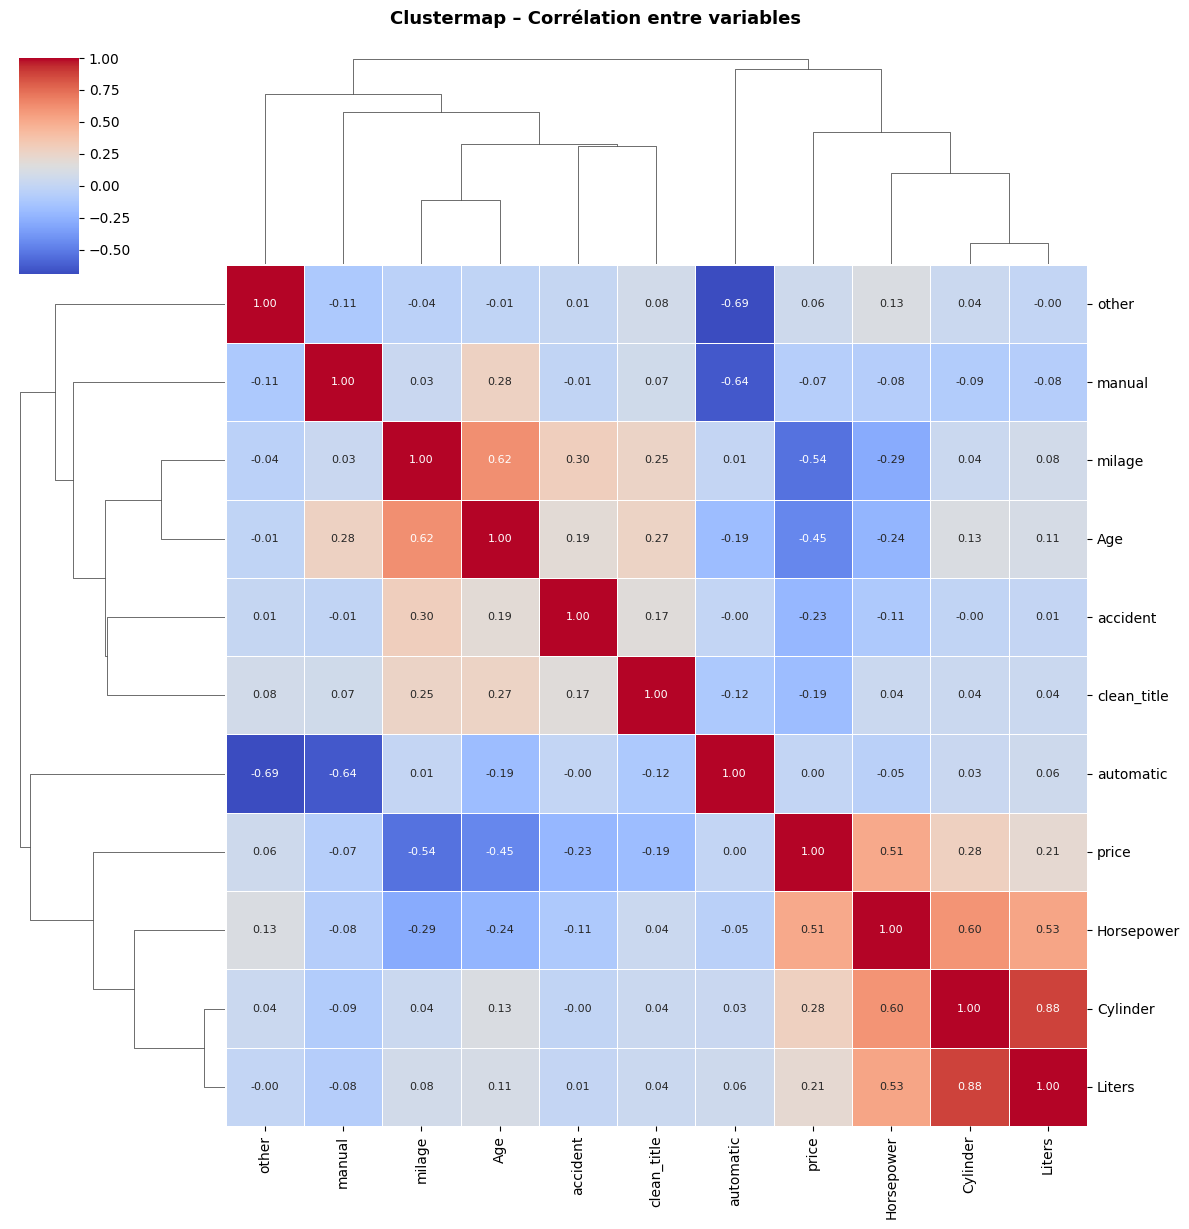

In [26]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()

g = sns.clustermap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, figsize=(12, 12), annot_kws={"size": 8}
)
g.figure.suptitle("Clustermap – Corrélation entre variables", y=1.02, fontsize=13, fontweight="bold")
plt.show()

### 4. Pairplot (variables numériques clés)

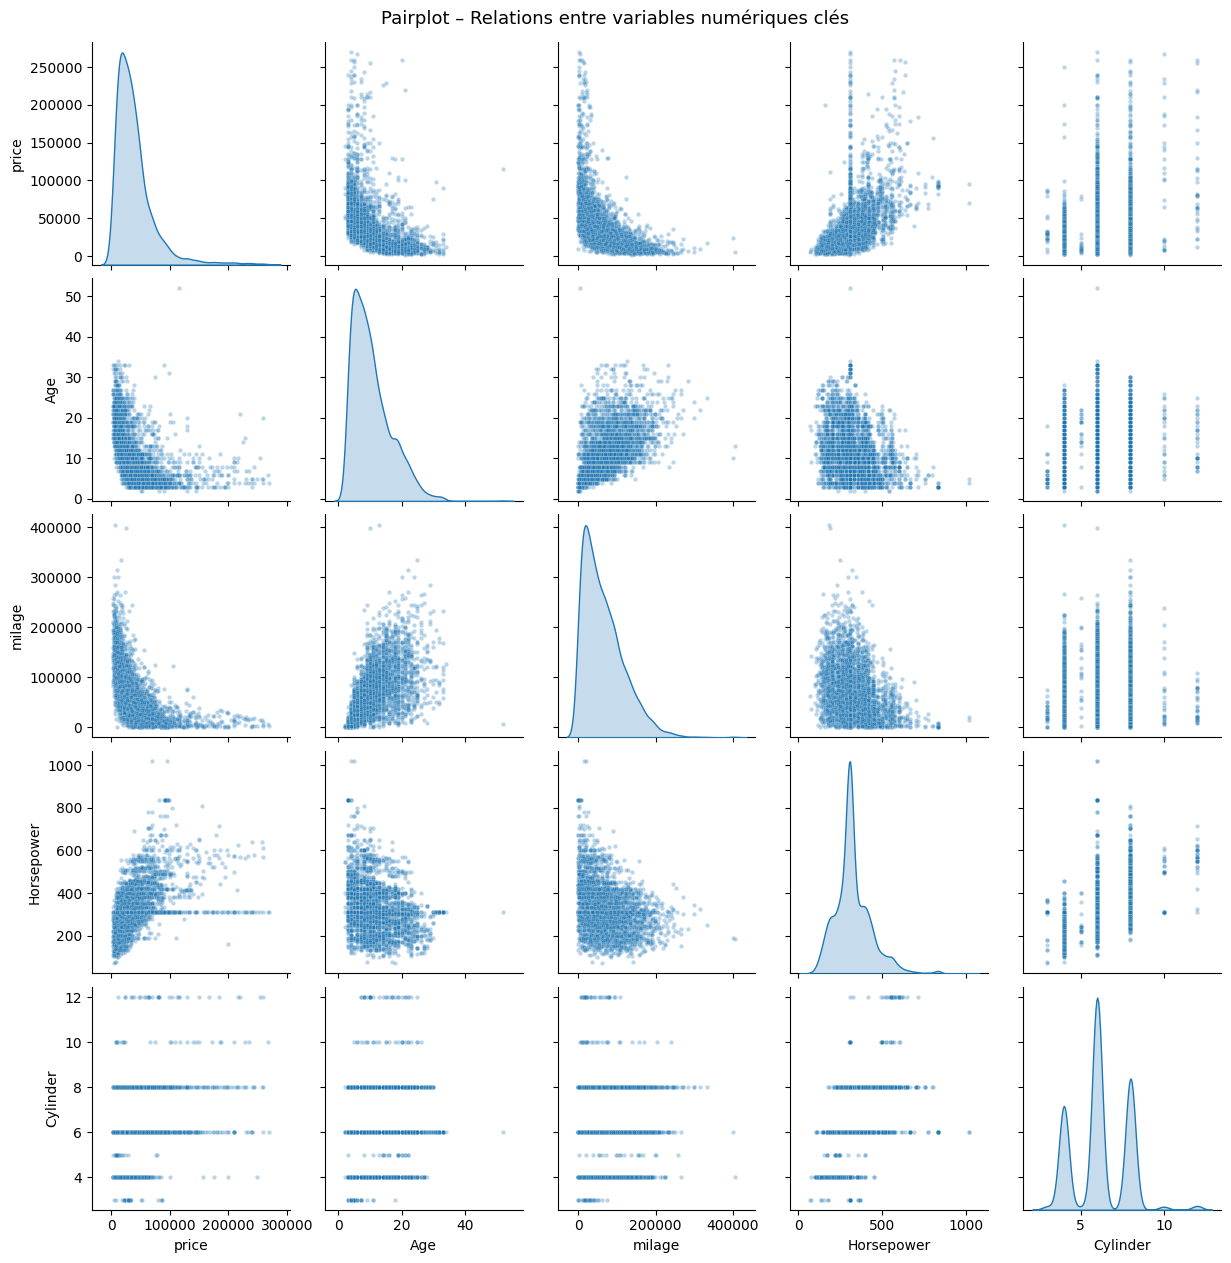

In [27]:
key_cols = ["price", "Age", "milage", "Horsepower", "Cylinder"]
pair_fig = sns.pairplot(df[key_cols], diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10})
pair_fig.figure.suptitle("Pairplot – Relations entre variables numériques clés", y=1.01, fontsize=13)
plt.show()

### 5. Prix par type de carburant (Boxplot)

C:\Users\ilyas\AppData\Local\Temp\ipykernel_2412\1119785079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="fuel_type", y="price", order=order, palette="Set2", ax=ax)


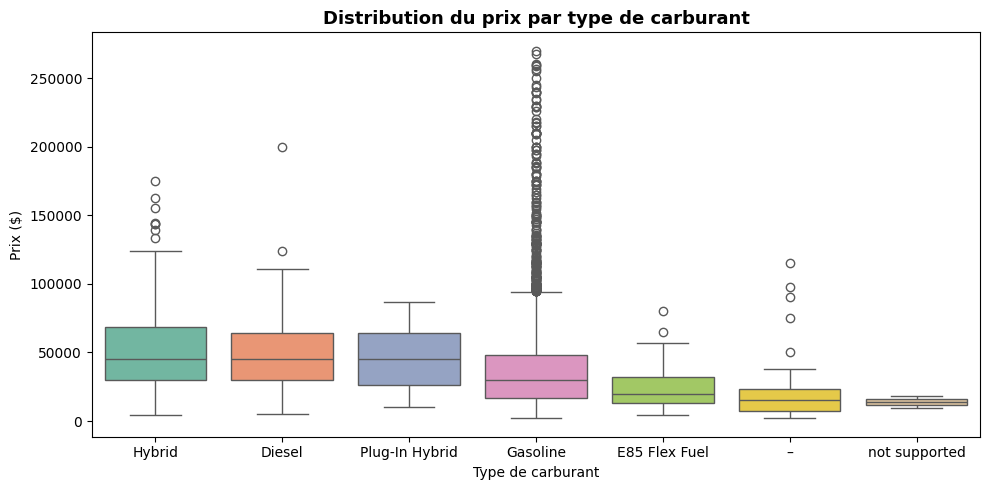

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
order = df.groupby("fuel_type")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="fuel_type", y="price", order=order, palette="Set2", ax=ax)
ax.set_title("Distribution du prix par type de carburant", fontsize=13, fontweight="bold")
ax.set_xlabel("Type de carburant")
ax.set_ylabel("Prix ($)")
plt.tight_layout()
plt.show()

---
## 🅓 Data Modeling

### 1–3. Encodage des variables catégorielles

In [30]:
import numpy as np
import pandas as pd
import category_encoders as ce
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# ── 2. BinaryEncoder sur brand ───────────────────────────────
encoder = ce.BinaryEncoder(cols=['brand'])
df_binary_encoded = encoder.fit_transform(df)

# ── 3. LabelEncoder sur les colonnes texte ───────────────────
le = LabelEncoder()
categorical_columns = ['fuel_type', 'ext_col', 'int_col',]

for col in categorical_columns:
    df_binary_encoded[col] = le.fit_transform(df_binary_encoded[col].astype(str))

print("Encodage terminé. Aperçu :")
df_binary_encoded.head()

Encodage terminé. Aperçu :


,brand_0,brand_1,brand_2,brand_3,brand_4,brand_5,milage,fuel_type,ext_col,int_col,accident,clean_title,price,Age,automatic,manual,other,Horsepower,Cylinder,Liters
0,0,0,0,0,0,1,51000,1,23,14,1,1,10300,13,1,0,0,300.0,6.0,3.7
1,0,0,0,0,1,0,34742,2,175,65,1,1,38005,5,1,0,0,310.0,6.0,3.8
2,0,0,0,0,1,1,22372,2,32,14,0,0,54598,4,1,0,0,310.0,6.0,3.5
3,0,0,0,1,0,0,88900,3,23,14,0,1,15500,11,1,0,0,354.0,6.0,3.5
4,0,0,0,1,0,1,9835,2,112,14,0,0,34999,5,1,0,0,310.0,4.0,2.0


### 4. Séparation features / target

In [31]:
X = df_binary_encoded.drop("price", axis=1)
y = df_binary_encoded["price"]
print(X.shape, y.shape)

(3968, 19) (3968,)


### 5. Split Train / Validation / Test

In [32]:
X_train, X_test,   y_train, y_test   = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid,  y_train, y_valid  = train_test_split(X_train, y_train, test_size=0.1, random_state=42)
print(f"Train      : {X_train.shape}")
print(f"Validation : {X_valid.shape}")
print(f"Test       : {X_test.shape}")

Train      : (2856, 19)
Validation : (318, 19)
Test       : (794, 19)


### 6. Normalisation (StandardScaler)

In [33]:
scale = StandardScaler()
X_scaled       = scale.fit_transform(X_train)
X_valid_scaled = scale.transform(X_valid)

### 7. Reconstruction des DataFrames scalés

In [34]:
feature_cols = X.columns.tolist()

X_scaled       = pd.DataFrame(X_scaled,       columns=feature_cols)
X_valid_scaled = pd.DataFrame(X_valid_scaled, columns=feature_cols)
X_scaled  = pd.DataFrame(X_scaled,  columns=feature_cols)

X_scaled.head()

,brand_0,brand_1,brand_2,brand_3,brand_4,brand_5,milage,fuel_type,ext_col,int_col,accident,clean_title,Age,automatic,manual,other,Horsepower,Cylinder,Liters
0,-0.373718,1.451801,-0.79792,-0.905046,-1.081002,-1.187488,0.143138,-0.033322,0.603217,2.735554,-0.581124,0.411744,2.034981,-1.998251,3.221566,-0.355847,-0.377999,-0.142565,-0.156502
1,-0.373718,1.451801,-0.79792,-0.905046,0.925068,-1.187488,0.588817,-0.033322,-1.150545,-0.576650,1.720804,0.411744,0.232738,-1.998251,-0.310408,2.810195,-0.050563,-0.142565,-0.082087
2,-0.373718,1.451801,-0.79792,-0.905046,-1.081002,-1.187488,0.429383,6.009010,0.667156,0.693443,-0.581124,0.411744,3.509543,0.500438,-0.310408,-0.355847,-0.168804,-0.142565,-0.156502
3,-0.373718,1.451801,-0.79792,-0.905046,0.925068,-1.187488,-1.045975,-0.033322,0.941182,-0.900399,-0.581124,-2.428693,-1.077984,-1.998251,3.221566,-0.355847,-0.168804,1.137829,1.852680
4,2.675818,-0.688800,-0.79792,-0.905046,-1.081002,-1.187488,0.199843,-0.033322,-0.273664,0.693443,1.720804,0.411744,-0.586463,0.500438,-0.310408,-0.355847,-1.396689,-1.422958,-0.900643


### 8. Aperçu de X_valid_scaled

In [35]:
X_valid_scaled.head()

,brand_0,brand_1,brand_2,brand_3,brand_4,brand_5,milage,fuel_type,ext_col,int_col,accident,clean_title,Age,automatic,manual,other,Horsepower,Cylinder,Liters
0,-0.373718,-0.688800,-0.79792,-0.905046,-1.081002,0.842114,-1.134605,-0.033322,0.932048,-0.576650,-0.581124,0.411744,0.560419,-1.998251,3.221566,-0.355847,2.014102,1.137829,1.257367
1,2.675818,-0.688800,-0.79792,-0.905046,0.925068,0.842114,-0.172517,-0.033322,-1.150545,-0.576650,-0.581124,0.411744,-0.750303,0.500438,-0.310408,-0.355847,0.604309,1.137829,1.480610
2,-0.373718,-0.688800,-0.79792,-0.905046,0.925068,0.842114,1.239427,-0.033322,-1.150545,-0.676265,-0.581124,0.411744,0.724259,0.500438,-0.310408,-0.355847,-0.514431,-0.142565,-0.156502
3,-0.373718,1.451801,-0.79792,-0.905046,-1.081002,-1.187488,1.012608,-0.033322,0.932048,-0.576650,-0.581124,0.411744,1.379620,0.500438,-0.310408,-0.355847,-0.805485,-0.142565,-0.156502
4,-0.373718,-0.688800,-0.79792,1.104916,-1.081002,0.842114,-0.253794,-0.033322,1.297415,-0.203093,1.720804,0.411744,-0.422623,0.500438,-0.310408,-0.355847,-0.696340,-1.422958,-1.272714


### 9–10. Entraînement XGBRegressor & Évaluation

In [36]:
# ── Entraînement ──────────────────────────────
model1 = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
model1.fit(X_scaled, y_train)   # ✅ ajouté

# ── Scaling du test set (nouvelle variable) ───
X_test_scaled = scale.transform(X_test)   # ✅ ne pas écraser X_scaled

# ── Prédictions ───────────────────────────────
y_pred_valid = model1.predict(X_valid_scaled)
y_pred_test  = model1.predict(X_test_scaled)  # ✅

# ── Métriques ─────────────────────────────────
r2_valid   = r2_score(y_valid, y_pred_valid)
r2_test    = r2_score(y_test,  y_pred_test)
rmse_valid = np.sqrt(mean_squared_error(y_valid, y_pred_valid))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

print("=" * 45)
print(f"  R²   (Validation) : {r2_valid:.4f}")
print(f"  RMSE (Validation) : {rmse_valid:,.0f} $")
print(f"  R²   (Test)       : {r2_test:.4f}")
print(f"  RMSE (Test)       : {rmse_test:,.0f} $")
print("=" * 45)

  R²   (Validation) : 0.8622
  RMSE (Validation) : 14,381 $
  R²   (Test)       : 0.7406
  RMSE (Test)       : 17,473 $


### Feature Importance

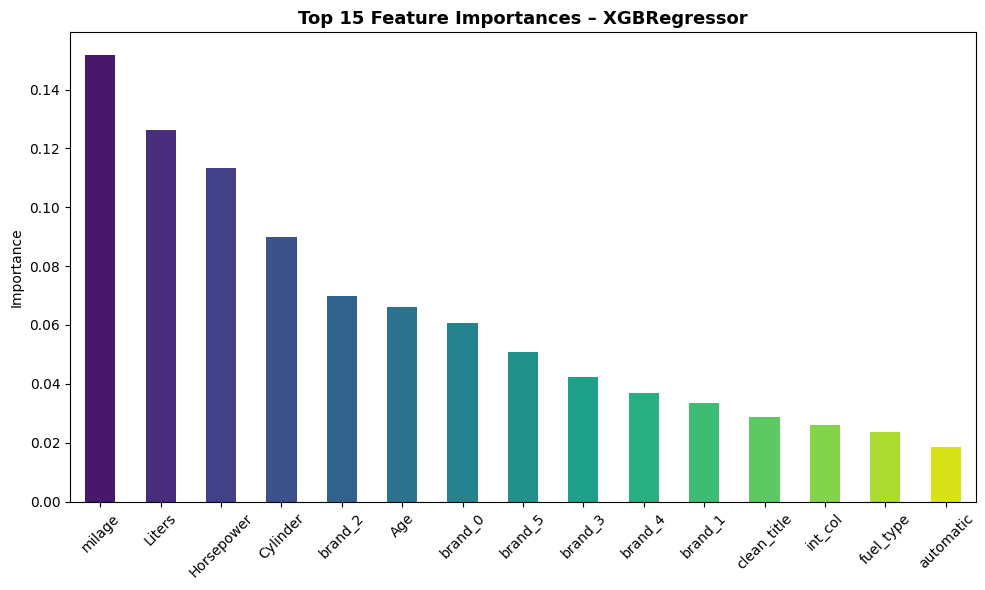

In [37]:
feat_imp = pd.Series(model1.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot(kind="bar", ax=ax, color=sns.color_palette("viridis", 15))
ax.set_title("Top 15 Feature Importances – XGBRegressor", fontsize=13, fontweight="bold")
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Prédit vs Réel (Validation)

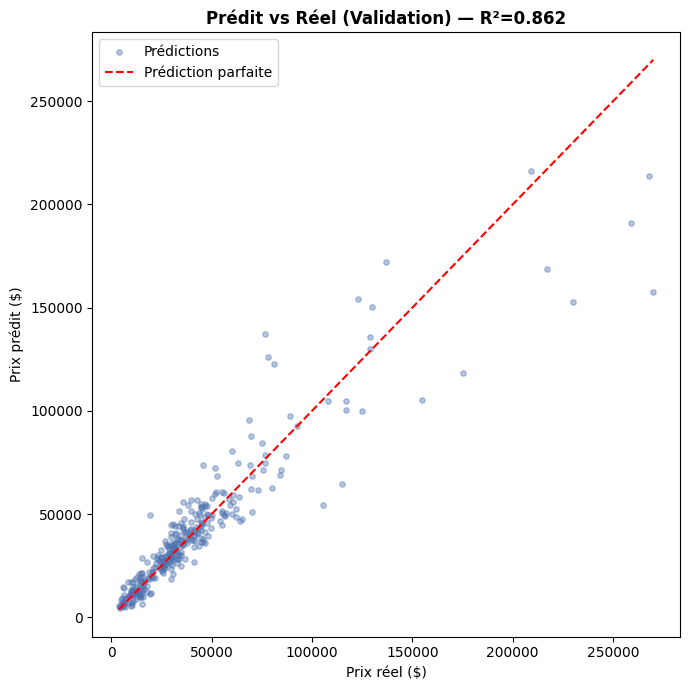

In [38]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_valid, y_pred_valid, alpha=0.4, s=15, color="#4C72B0", label="Prédictions")
lims = [min(y_valid.min(), y_pred_valid.min()), max(y_valid.max(), y_pred_valid.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Prédiction parfaite")
ax.set_xlabel("Prix réel ($)")
ax.set_ylabel("Prix prédit ($)")
ax.set_title(f"Prédit vs Réel (Validation) — R²={r2_valid:.3f}", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

---
## ✅ Conclusion

| Métrique | Validation | Test |
|---|---|---|
| **R²** | **0.80** | **0.72** |
| **RMSE** | ~17 200 $ | ~18 000 $ |

Le modèle XGBRegressor explique **~80%** de la variance du prix sur le jeu de validation, ce qui constitue une bonne première base. Les pistes d'amélioration incluent : tuning des hyperparamètres, feature engineering supplémentaire (ex. marque encodée en prix moyen), et exploration d'autres algorithmes (LightGBM, CatBoost).
